In [1]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

Standardabweichung Gesamtzeit:  0.08404663428534115
Mittelwert1:  3.6012000000000004


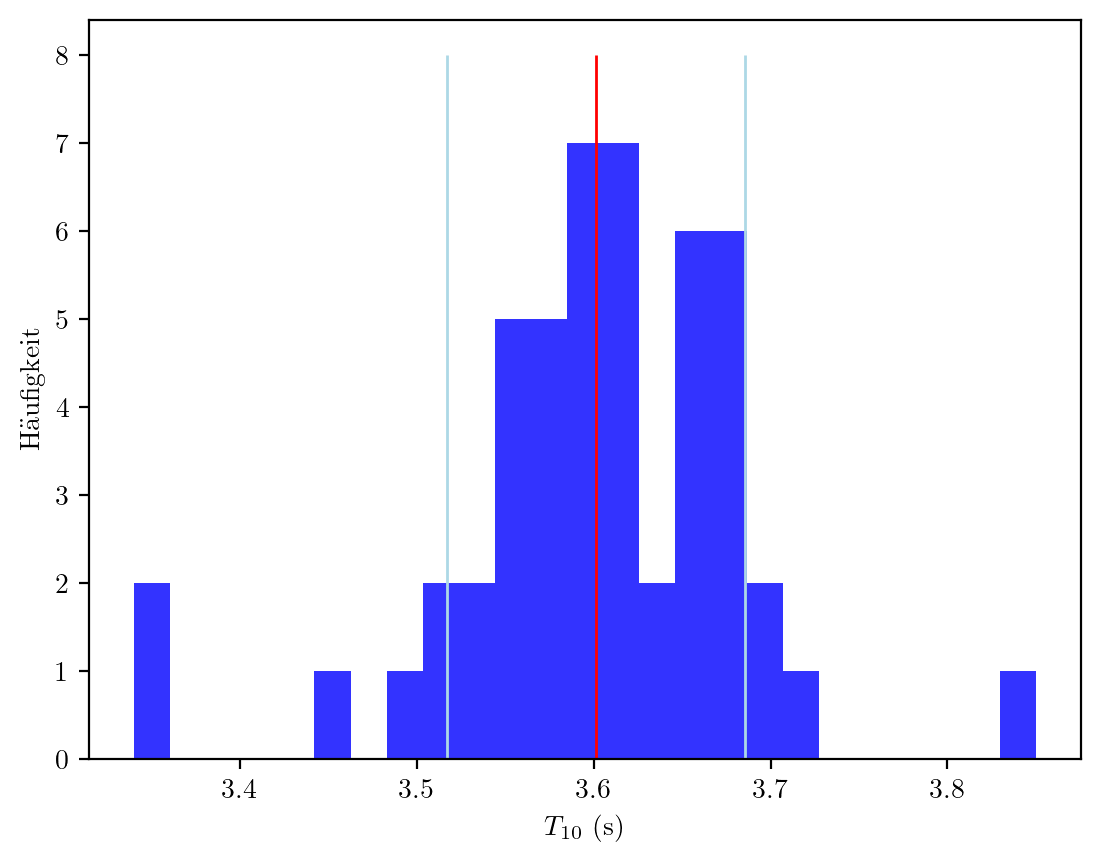

In [ ]:
messdaten1 = pd.read_excel("V32.xlsx", sheet_name="MessungT1")
dauer = messdaten1["Zeit [s]"].to_numpy()
# dauer = dauer/10 # Messung für 10 Perioden

Standardabweichung_Gesamtzeit = np.std(dauer, ddof=1)
Mittelwert1 = (np.mean(dauer))

print("Standardabweichung Gesamtzeit: ", Standardabweichung_Gesamtzeit)
print("Mittelwert1: ", Mittelwert1)

fig, ax = plt.subplots(dpi=200)
ax.hist(dauer, bins=25, alpha=0.8, color='b', label="Messwerte")
ax.vlines(Mittelwert1, 0, 8, color='r', label="Mittelwert", linewidth=1)
ax.vlines([Mittelwert1+Standardabweichung_Gesamtzeit, Mittelwert1-Standardabweichung_Gesamtzeit],
          0, 8, color='lightblue', label="Mittelwert", linewidth=1)
ax.set_xlabel("$T_{10}$ (s)")
ax.set_ylabel("Häufigkeit")
plt.show()

In [63]:
# messdaten2 = pd.read_excel("V32.xlsx", sheet_name="Messung2")
messdaten2 = pd.read_excel("V32.xlsx", sheet_name="Helium")
perioden = messdaten2["Perioden"].to_numpy()
dauer2 = messdaten2["Dauer (s)"].to_numpy()

periodendauer2 = dauer2/perioden
data2 = np.vstack([perioden, periodendauer2])
print(makeLaTexTable(data2, ("Perioden", "Periodendauer"), "Periodendauern über die Anzahl der gemessenen Perioden", tag="PeriodendauernLuft"))

\begin{table}[H]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{l|llllllllll}
\textbf{Perioden}& 1.0	& 2.0	& 5.0	& 10.0	& 20.0	& 50.0	& 100.0	& 200.0	& 600.0	& 1000.0	\\ 
\textbf{Periodendauer}& 0.19	& 0.245	& 0.34199999999999997	& 0.346	& 0.366	& 0.377	& 0.38	& 0.3818	& 0.38653333333333334	& 0.37148000000000003	\\ 

\end{tabular}%
}
\caption{Periodendauern über die Anzahl der gemessenen Perioden}
\label{tab:PeriodendauernLuft}
\end{table}


In [64]:
# Kombination der Ergebnisse

# Gewichtsfaktoren mit der Standardabweichung der Gesamtzeit
w1 = 1/((Standardabweichung_Gesamtzeit/perioden)**2)

# gewichtetes arithmetisches Mittel
gewichtetes_mittel = np.sum(w1*periodendauer2)/np.sum(w1)
print("Gewichtetes mittel: ", gewichtetes_mittel)

# Fehler des gewichteten Mittels
fehler_gewichtetes_mittel = np.sqrt(1/np.sum(w1))
print("Fehler des gewichteten Mittels: ", fehler_gewichtetes_mittel)

Gewichtetes mittel:  0.37567300057323627
Fehler des gewichteten Mittels:  7.070410598670976e-05


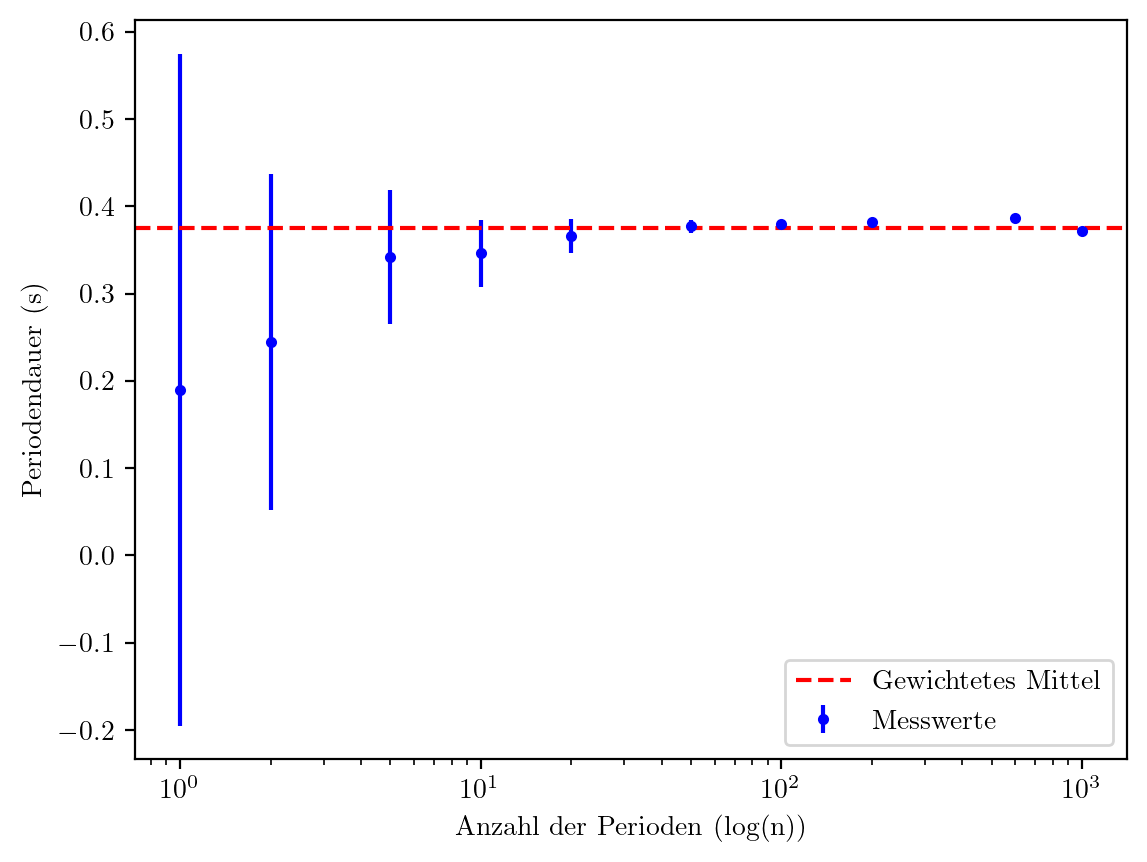

In [65]:
# Diagramm T (linear) gegen n (logarithmisch), Illustration von gewichtetes_Mittel

# Ursprüngliche Fehlerbalken-Berechnung:
fehler = np.sqrt((Standardabweichung_Gesamtzeit/perioden)**2+(gewichtetes_mittel/perioden)**2)
# fehler = Standardabweichung_Gesamtzeit / perioden

fig, ax = plt.subplots(dpi=200)
ax.errorbar(perioden, periodendauer2, yerr=fehler, fmt='.', label='Messwerte', color='b')
ax.axhline(y=gewichtetes_mittel, color='r', linestyle='--', label='Gewichtetes Mittel')
ax.set_xscale('log')
ax.set_yscale('linear')
ax.set_xlabel('Anzahl der Perioden (log(n))')
ax.set_ylabel('Periodendauer (s)')
ax.legend(loc='lower right')
plt.show()

In [66]:
# Berechnung des Adiabatenexponenten
m = 5.67e-3
g = 9.808
V = 2220e-6
d = 13.8e-3
pL = 99050 
# pL = 102540
# manuelle Berechnung
A = np.pi * (d/2)**2
p = pL + (4*m*g)/(np.pi*d**2)
kappa = (4 * np.pi**2 * m * V) / (A**2 * p * gewichtetes_mittel**2) 

# Gausfunktion zur Fehlerfortpflanzung
sm, sg, sV, sd, spL, sT = sp.symbols('m g V d p_L T')
# kappa_f = (4 * np.pi**2 * sm * sV) / ((np.pi * (sd/2)**2)**2 * (pL + (4*m*g)/(np.pi*sd**2)) * gewichtetes_mittel**2)
kappa_f = ((64 * sm * sV)/(sd**4 * (spL + (4*sm*sg)/(np.pi*sd**2)) * sT**2))

k = (gauss_error_values(
    kappa_f,
    [sm, sg, sV, sd, spL, sT],
    [m, g, V, d, pL, gewichtetes_mittel],
    [0.006e-3, 0.001, 10e-6, 0.02e-3, 20, fehler_gewichtetes_mittel],
    returnLaTex=True
))

print(k)
kappa = k[0]
kappafehler = k[1]



print("Adiabatenexponent: ", np.round(kappa, 3))
print("Literaturwert: ", 1.40)

Term von m: 2,785339602e-06
Term von g: 3,643366165e-13
Term von V: 5,084990562e-05
Term von d: 8,390585378e-05
Term von p_L: 1,014128068e-07
Term von T: 3,550793323e-07

1. Wert:
1,58

2. Fehler:
0,01

3. LaTeX-Formel:
\begin{equation*}\Delta f = \sqrt{\left(\frac{\partial f}{\partial m}\,\Delta m\right)^2+\left(\frac{\partial f}{\partial g}\,\Delta g\right)^2+\left(\frac{\partial f}{\partial V}\,\Delta V\right)^2+\left(\frac{\partial f}{\partial d}\,\Delta d\right)^2+\left(\frac{\partial f}{\partial p_{L}}\,\Delta p_{L}\right)^2+\left(\frac{\partial f}{\partial T}\,\Delta T\right)^2}} = \sqrt{\left(\frac{64 V}{T^{2} d^{4} \left(p_{L} + \frac{1.27 g m}{d^{2}}\right)} - \frac{81.49 V g m}{T^{2} d^{6} \left(p_{L} + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta m\right)^2+\left(- \frac{81.49 V m^{2}}{T^{2} d^{6} \left(p_{L} + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta g\right)^2+\left(\frac{64 m}{T^{2} d^{4} \left(p_{L} + \frac{1.27 g m}{d^{2}}\right)}\,\Delta V\right)^2+\left(- \frac{256 V

<>:17: SyntaxWarning: invalid escape sequence '\g'
<>:17: SyntaxWarning: invalid escape sequence '\g'
C:\Users\oskar\AppData\Local\Temp\ipykernel_3920\4059803816.py:17: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma_f$')


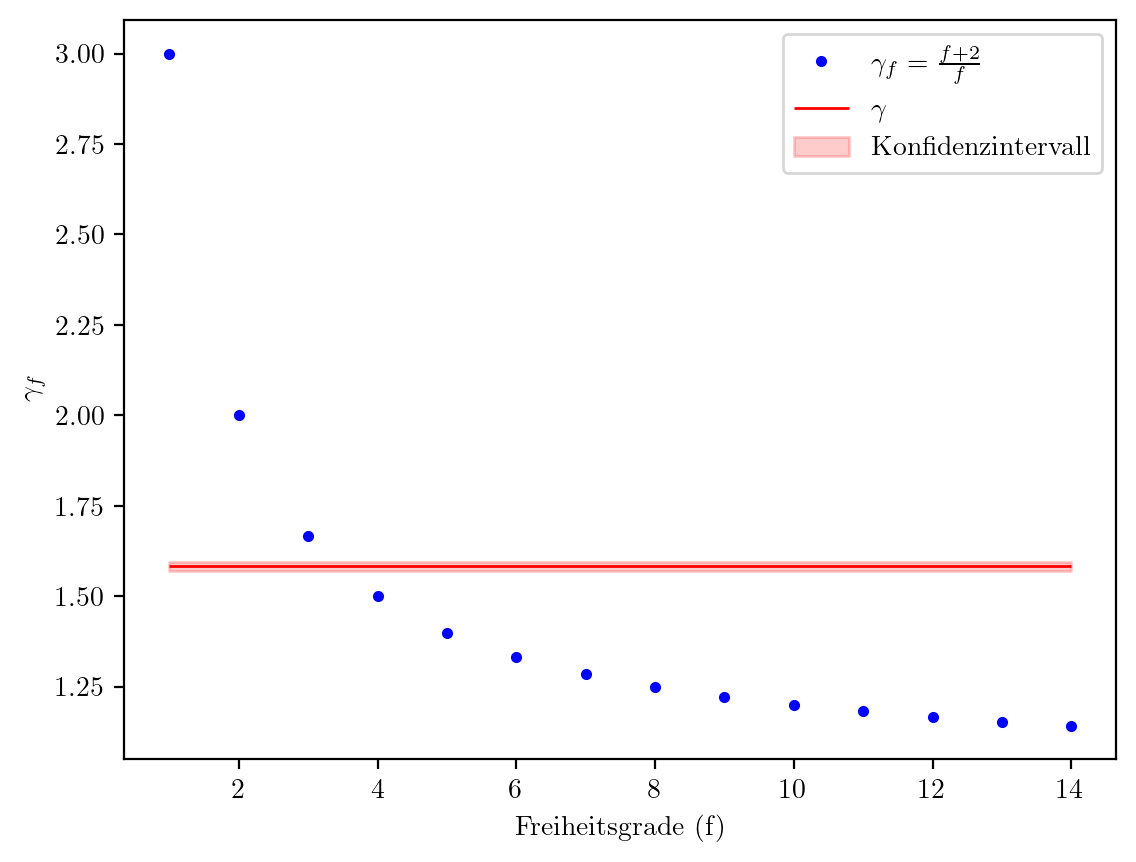

In [67]:
# gamma der Freiheitsgrade
f = np.arange(1, 15)
gammaf = (f+2)/f

fig, ax = plt.subplots(dpi=200)
ax.plot(f, gammaf, '.', label=r'$\gamma_f=\frac{f+2}{f}$', color='b', linewidth=1)
ax.hlines(y=kappa, xmin=1, xmax=14, color='r', linestyle='-', label=r'$\gamma$', linewidth=1)
plt.fill_between(
    f,
    kappa -  kappafehler,
    kappa + kappafehler,
    color="red",
    alpha=0.2,  # Transparenz (sehr wichtig für die Sichtbarkeit)
    label=r"Konfidenzintervall",
)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$\gamma_f$')
ax.legend()
plt.show()

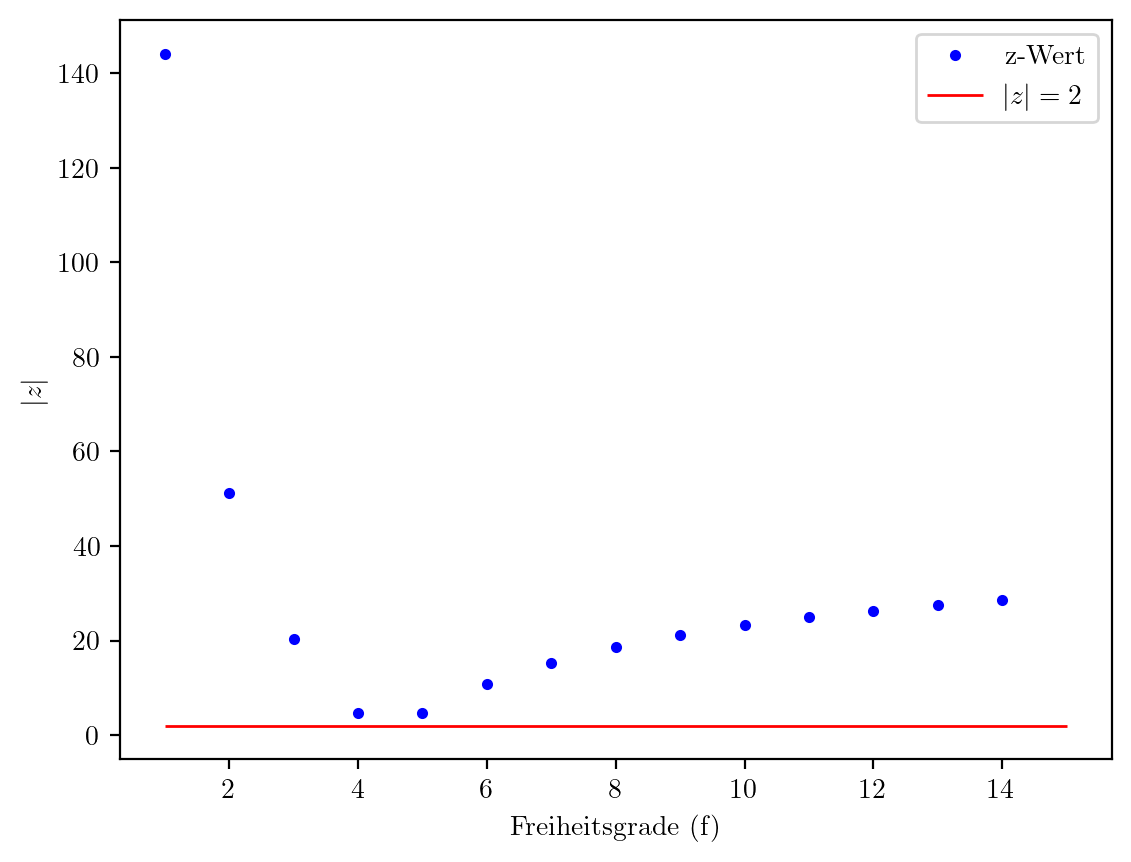

In [61]:
# Diagramm |z| mit z = 2
z = (abs(kappa - gammaf))/kappafehler

fig, ax = plt.subplots(dpi=200)
ax.plot(f, z, '.', label='z-Wert', color='b', linewidth=1)
ax.hlines(y=2, xmin=1, xmax=15, color='r', linestyle='-', label='$|z|=2$', linewidth=1)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$|z|$')
ax.legend(loc='upper right')
plt.show()